looking at the stats from the assignment


H0: test that fitness of final result is not correlated with number crossover points (sanity check) OR possibly more crossover points correlated with higher fitness?[AG3.1]
- Visual: plot final fitness values vs nr of crossovers, look for pattern
- Inference test: linear regression, does nr of crossovers predict fitness?


H1: compare how many generations it takes to get to the final fitness value per number of crossover points? Quicker to plateau if more crossover points
- Visual: Plot fitness per generation, compare lines per nr of crossover points
- Inference test: linear regression: does the nr of crossover points predict the nr of generations when the fitness plateaus?[AG4.1][AG4.2]


H2: comparing tree similarity between final trees: the more homogenous the crossover, the higher the tree similarity within optimal results (NOT between results and target)
- Visual: Compare plots showing tree similarity on y and nr of crossovers on x
- Inference test: linear regression predicting sd


get all final robot trees
calculate their distance to each target, save
make plot of what they look like, save
save all as vector files at the end for usability
check lables, titles, colours

In [263]:
#install packages
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import names
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import statsmodels.api as sm

#from ariel
#from project
#from A1_working import plot_stats

#to make font computer modern like in latex
fpath = Path(mpl.get_data_path(), "fonts/ttf/cmr10.ttf")
prop = mpl.font_manager.FontProperties(fname=fpath)
mpl.font_manager.fontManager.addfont(str(fpath))
mpl.rcParams["font.family"] = prop.get_name()

In [264]:
#import all data
base_path = Path("C:/Users/anton/Documents/EvolutionaryComputing2026/assignments/assignment_1/__data__/__data__/A1_template_2026")

dfs = []
headers = ["best", "mean", "std", "worst"]

#per crossover condition
for point_folder in base_path.glob("point-*_parent-3"):
    #per exp/seed rerun
    for exp_folder in point_folder.glob("exp*"):
        #import statistics general_stats
        stats_file = exp_folder / "statistics" / "general_stats"

        if stats_file.exists():
            df = pd.read_csv(stats_file, sep=r"\s+", names=headers)

            # Add time information
            df["gen"] = range(len(df))

            # Keep track of where each dataset came from
            df["point"] = int(point_folder.name.split("-")[1].split("_")[0])
            df["experiment"] = int(exp_folder.name.replace("exp", ""))

            dfs.append(df)

general_stats = pd.concat(dfs, ignore_index=True)
#print(dfs[5])
print(general_stats)



#calculate rate of change between fitness between generations
#seperate: calculate the generation where the rate is under 0.05?
#add to dataset
#import baseline
#import also per target 0 1 2 3 4

       best   mean   std  worst  gen  point  experiment
0     15.98  20.77  1.12  23.00    0     10           0
1     15.98  20.76  1.12  23.00    1     10           0
2     15.98  20.71  1.16  23.00    2     10           0
3     15.98  20.68  1.17  23.00    3     10           0
4     15.98  20.63  1.20  22.86    4     10           0
...     ...    ...   ...    ...  ...    ...         ...
9995  15.06  16.94  1.34  21.42   95      9           9
9996  15.06  16.90  1.31  21.42   96      9           9
9997  15.06  16.87  1.28  21.42   97      9           9
9998  15.06  16.86  1.28  21.42   98      9           9
9999  15.06  16.82  1.24  21.42   99      9           9

[10000 rows x 7 columns]


In [265]:
#get baseline data
dfs = []
headers = ["best", "mean", "std", "worst"]

#per crossover condition
for point_folder in base_path.glob("point-*_parent-3"):
    #per exp/seed rerun
    for exp_folder in point_folder.glob("exp*"):
        #import statistics general_stats
        stats_file = exp_folder / "statistics" / "baseline_stats"

        if stats_file.exists():
            df = pd.read_csv(stats_file, sep=r"\s+", names=headers)

            # Add time information
            df["gen"] = range(len(df))

            # Keep track of where each dataset came from
            df["point"] = int(point_folder.name.split("-")[1].split("_")[0])
            df["experiment"] = int(exp_folder.name.replace("exp", ""))

            dfs.append(df)

baseline_stats = pd.concat(dfs, ignore_index=True)
#print(dfs[5])
print(general_stats.head())

    best   mean   std  worst  gen  point  experiment
0  15.98  20.77  1.12  23.00    0     10           0
1  15.98  20.76  1.12  23.00    1     10           0
2  15.98  20.71  1.16  23.00    2     10           0
3  15.98  20.68  1.17  23.00    3     10           0
4  15.98  20.63  1.20  22.86    4     10           0


     point  gen    mean    std    best   worst
0        1    0  20.798  1.024  18.003  23.383
1        1    1  20.763  1.048  17.721  23.383
2        1    2  20.726  1.061  17.580  23.302
3        1    3  20.664  1.114  17.131  23.302
4        1    4  20.619  1.155  16.775  23.302
..     ...  ...     ...    ...     ...     ...
995     10   95  16.795  1.127  14.957  21.621
996     10   96  16.785  1.120  14.957  21.621
997     10   97  16.763  1.120  14.941  21.621
998     10   98  16.751  1.108  14.941  21.621
999     10   99  16.737  1.102  14.941  21.621

[1000 rows x 6 columns]
     point  gen    mean    std    best   worst
0        1    0  20.800  1.008  18.199  23.383
1        1    1  20.772  1.006  18.199  23.383
2        1    2  20.730  1.023  17.883  23.338
3        1    3  20.702  1.022  17.883  23.174
4        1    4  20.668  1.028  17.712  23.130
..     ...  ...     ...    ...     ...     ...
995     10   95  17.967  1.046  16.090  21.507
996     10   96  17.945  1.044  16.

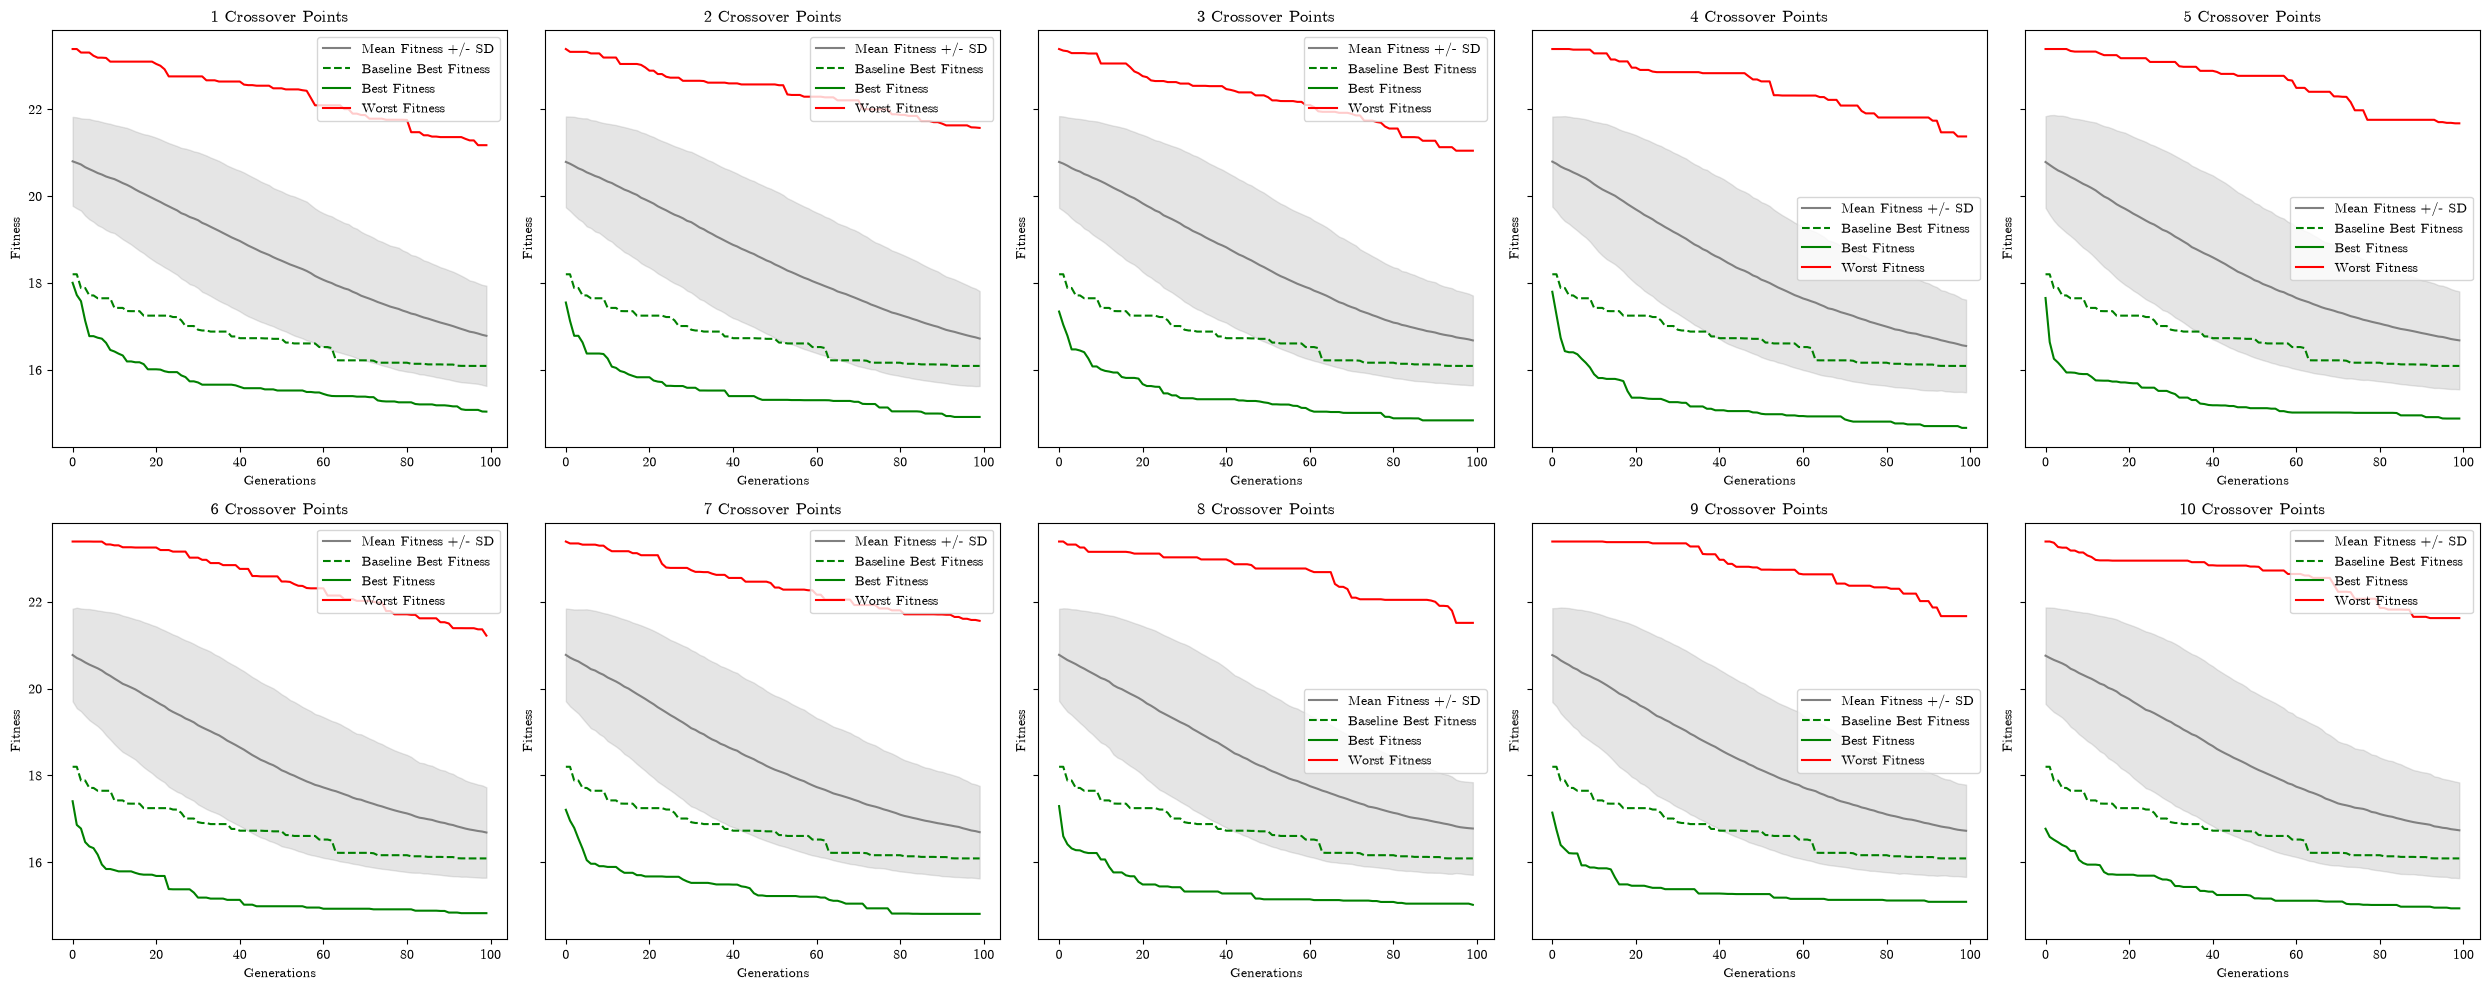

In [266]:
#merge general stats over seed reruns
mean_over_seeds = (
    general_stats.groupby(["point", "gen"], as_index=False)
        .agg({
            "mean": "mean",
            "std": "mean",
            "best": "mean",
            "worst": "mean"
        })
)
print(mean_over_seeds)

#merge baseline over seed reruns
mean_baseline_over_seeds = (
    baseline_stats.groupby(["point", "gen"], as_index=False)
        .agg({
            "mean": "mean",
            "std": "mean",
            "best": "mean",
            "worst": "mean"
        })
)
print(mean_baseline_over_seeds)

#call same plots as before
amount_of_plots=len(mean_over_seeds["point"].unique()) # one for each param configuration
timesteps = 100

fig, axes = plt.subplots(2,5,figsize=(25,10),sharey=True)
axes = axes.flatten()

for ax, experiment in zip(axes, mean_over_seeds["point"].unique()):

    # Get data for this experiment
    exp_data = mean_over_seeds[mean_over_seeds["point"] == experiment].sort_values("gen")
    base_data = mean_baseline_over_seeds[mean_baseline_over_seeds["point"] == experiment].sort_values("gen")

    mean = exp_data["mean"].values
    std = exp_data["std"].values
    best = exp_data["best"].values
    worst = exp_data["worst"].values
    time = exp_data["gen"].values
    baseline = base_data["best"].values

    upper = mean + std
    lower = mean - std

    ax.plot(time,mean,color="gray", label="Mean Fitness +/- SD")
    ax.plot(time,baseline,color="green",linestyle = "--", label="Baseline Best Fitness")
    ax.plot(time,best,color="green",label="Best Fitness")
    ax.plot(time,worst,color="red",  label="Worst Fitness")
    ax.fill_between(time,lower,upper,color="gray",alpha=0.2)

    ax.set_title(f"{experiment} Crossover Points")
    ax.set_xlabel("Generations")
    ax.set_ylabel("Fitness")
    ax.legend()

plt.tight_layout()

fig.savefig("overview_graph.pdf", format="pdf", bbox_inches="tight")
fig.savefig("overview_graph.svg", format="svg", bbox_inches="tight")


plt.show()
    


In [267]:
#plot in which generation the rate of change stops per crossover condition
#convergence defined as when it hits the final best fitness value
tolerance = 0.5 #how much away from final value are we counting as converge?

# convergence = (
#     general_stats.sort_values(["point", "experiment", "gen"])
#       .groupby(["point", "experiment"])
#       .apply(
#           lambda x: pd.Series({
#               "final_best": x["best"].iloc[-1],
#               "convergence_gen": x.loc[
#                   np.isclose(
#                       x["best"],
#                       x["best"].iloc[-1],
#                       atol=tolerance
#                   ),
#                   "gen"
#               ].iloc[0]
#           })
#       )
#       .reset_index()
# )
convergence = (
    general_stats.sort_values(["point", "experiment", "gen"])
      .groupby(["point", "experiment"])
      .apply(
          lambda x: pd.Series({
              "final_best": x["best"].iloc[-1],
              "convergence_gen": (
                  x.loc[x["best"] < 16, "gen"].iloc[0]
                  if (x["best"] < 16).any()
                  else np.nan
              )
          })
      )
      .reset_index()
)



convergence_baseline = (
    baseline_stats.sort_values(["point", "experiment", "gen"])
      .groupby(["point", "experiment"])
      .apply(
          lambda x: pd.Series({
              "final_best": x["best"].iloc[-1],
              "convergence_gen": (
                  x.loc[x["best"] < 16, "gen"].iloc[0]
                  if (x["best"] < 16).any()
                  else np.nan
              )
          })
      )
      .reset_index()
)

print(convergence_baseline)
#do this per crossover point and add to plot above to show when final fitness is reached


    point  experiment  final_best  convergence_gen
0       1           0       16.16              NaN
1       1           1       15.68             40.0
2       1           2       16.47              NaN
3       1           3       15.77             72.0
4       1           4       15.88             62.0
..    ...         ...         ...              ...
95     10           5       16.36              NaN
96     10           6       16.35              NaN
97     10           7       16.46              NaN
98     10           8       16.61              NaN
99     10           9       15.16             63.0

[100 rows x 4 columns]


In [308]:
#linear regression
#predict final fitness values using crossover points
x = convergence["point"].to_numpy()
#make it fit statsmodel convention
X = sm.add_constant(x)
y= convergence["final_best"].to_numpy()

#fit linear regression model
regr_h0 = sm.OLS(y, X).fit()

#view model summary
print(regr_h0.summary())

#add test to compare to baseline?

#for plot:
x_line = np.linspace(
    convergence["point"].min(),
    convergence["point"].max(),
    100
).reshape(-1, 1)
X_line = sm.add_constant(x_line)

y_line = regr_h0.predict(X_line)

#the slope explains about 1 percent of variance Rsquared = 0.01, not significant, p = 0.386




                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.7574
Date:                Sat, 19 Sep 2026   Prob (F-statistic):              0.386
Time:                        15:36:24   Log-Likelihood:                -32.128
No. Observations:                 100   AIC:                             68.26
Df Residuals:                      98   BIC:                             73.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.8469      0.073    203.917      0.0

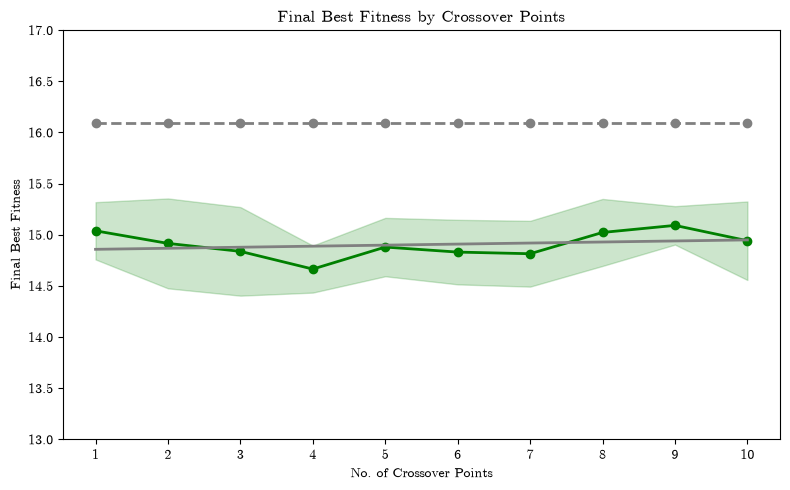

In [309]:
##plot final best fitness by crossover points
final_best_by_point = (
    convergence
    .groupby("point")["final_best"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("point")
)

baseline_best_by_point = (
    convergence_baseline
    .groupby("point")["final_best"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("point")
)

# plt.scatter(
#     convergence["point"],
#     convergence["final_best"],
#     s=80
# )

plt.figure(figsize=(8, 5))

plt.plot(
    final_best_by_point["point"],
    final_best_by_point["mean"],
    marker="o",
    linewidth=2,
    color="green",
    label="Average Final Best"
)
plt.plot(
    baseline_best_by_point["point"],
    baseline_best_by_point["mean"],
    marker="o",
    linewidth=2,
    color="gray",
    linestyle = "--",
    label="Baseline Average Final Best"
)

# Shaded SD
plt.fill_between(
    final_best_by_point["point"],
    final_best_by_point["mean"] - final_best_by_point["std"],
    final_best_by_point["mean"] + final_best_by_point["std"],
    color="green",
    alpha=0.2,
    label="± SD"
)

#add linear regression line
plt.plot( 
    x_line,
    y_line,
    color="grey",
    linewidth=2,
    label="Linear regression"
)

plt.ylim(13, 17)
plt.xticks(final_best_by_point["point"])
plt.xlabel("No. of Crossover Points")
plt.ylabel("Final Best Fitness")
plt.title("Final Best Fitness by Crossover Points")

plt.tight_layout()
fig.savefig("final_fitness_graph.pdf", format="pdf", bbox_inches="tight")
fig.savefig("final_fitness.svg", format="svg", bbox_inches="tight")

plt.show()
#print(final_best_by_point)

In [306]:
x = convergence["point"].to_numpy() 
#add constant to predictor variables
X = sm.add_constant(x)
y= convergence["convergence_gen"].to_numpy()



#fit linear regression model
regr_h1 = sm.OLS(y, X).fit()

#view model summary
print(regr_h1.summary())

#for plot:
x_line = np.linspace(
    convergence["point"].min(),
    convergence["point"].max(),
    100
).reshape(-1, 1)
X_line = sm.add_constant(x_line)
y_line = regr_h1.predict(X_line)
# #add to plot?
#Rsquared 0.01 also explains about 1 percent of variance, p = 0.241

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.392
Date:                Sat, 19 Sep 2026   Prob (F-statistic):              0.241
Time:                        15:35:24   Log-Likelihood:                -387.60
No. Observations:                 100   AIC:                             779.2
Df Residuals:                      98   BIC:                             784.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.7333      2.547      6.178      0.0

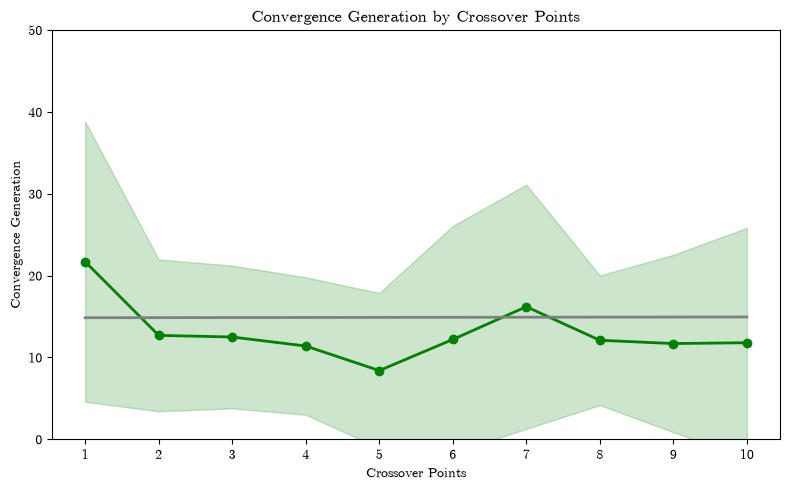

In [310]:
##plot convergence gen by crossover points
convergence_by_point = (
    convergence
    .groupby("point")["convergence_gen"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("point")
)

convergence_by_point_baseline = (
    convergence_baseline
    .groupby("point")["convergence_gen"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("point")
)


# plt.scatter(
#     convergence["point"],
#     convergence["final_best"],
#     s=80
# )

plt.figure(figsize=(8, 5))

plt.plot(
    convergence_by_point["point"],
    convergence_by_point["mean"],
    marker="o",
    linewidth=2,
    color="green",
    label="Average Final Best"
)


# plt.plot(
#     convergence_by_point_baseline["point"],
#     convergence_by_point_baseline["mean"],
#     marker="o",
#     linewidth=2,
#     color="gray",
#     linestyle = "--",
#     label="Average Final Best"
# )

# Shaded SD
plt.fill_between(
    convergence_by_point["point"],
    convergence_by_point["mean"] - convergence_by_point["std"],
    convergence_by_point["mean"] + convergence_by_point["std"],
    color="green",
    alpha=0.2,
    label="± SD"
)

#add linear regression line
plt.plot( 
    x_line[0:],
    y_line[0:],
    color="grey",
    linewidth=2,
    label="Linear regression"
)


plt.ylim(0, 50)
plt.xticks(final_best_by_point["point"])
plt.xlabel("Crossover Points")
plt.ylabel("Convergence Generation")
plt.title("Convergence Generation by Crossover Points")

plt.tight_layout()
fig.savefig("convergence_gen_graph.pdf", format="pdf", bbox_inches="tight")
fig.savefig("convergence_gen_graph.svg", format="svg", bbox_inches="tight")

plt.show()
#no baseline siince convergence is calculated in relation to reaching thre optimal baseline level

In [272]:
#get data for distance to targets 
target_dfs = []

headers = ["best", "mean", "std", "worst"]

for target in range(10):

    dfs = []

    # Per crossover condition
    for point_folder in base_path.glob("point-*_parent-3"):

        # Per experiment/seed rerun
        for exp_folder in point_folder.glob("exp*"):

            # Import target statistics
            stats_file = (
                exp_folder
                / "statistics"
                / f"target_{target}_stats"
            )

            if stats_file.exists():
                df = pd.read_csv(
                    stats_file,
                    sep=r"\s+",
                    names=headers
                )

                # Add generation information
                df["gen"] = range(len(df))

                # Keep track of where each dataset came from
                df["point"] = int(
                    point_folder.name.split("-")[1].split("_")[0]
                )

                df["experiment"] = int(
                    exp_folder.name.replace("exp", "")
                )

                # Keep track of target
                df["target"] = target

                dfs.append(df)

    # Combine all experiments/points for this target
    if dfs:
        target_dfs.append(
            pd.concat(dfs, ignore_index=True)
        )

# Combine all targets
target_stats = pd.concat(
    target_dfs,
    ignore_index=True
)

final_best = target_stats[
    target_stats["gen"] == 49
][["point", "experiment", "target", "best"]].copy()

#print(target_stats.head())
print(final_best)


       point  experiment  target  best
49        10           0       0   4.0
149       10           1       0   4.0
249       10           2       0   3.5
349       10           3       0   4.0
449       10           4       0   4.0
...      ...         ...     ...   ...
49549      9           5       4  16.0
49649      9           6       4  16.5
49749      9           7       4  16.0
49849      9           8       4  16.5
49949      9           9       4  16.5

[500 rows x 4 columns]


In [273]:
#get more correct data
distances_df = pd.read_csv( "tree_distances.csv")
print(distances_df)

stats_by_point = (
    distances_df
    .groupby("point")["distance"]
    .agg(
        mean="mean",
        std="std",
        variance="var"
    )
    .reset_index()
)

print(stats_by_point)


     point  experiment_1  experiment_2  distance
0        1             0             1       8.5
1        1             0             2       8.5
2        1             0             3       6.5
3        1             0             4       5.5
4        1             0             5       7.5
..     ...           ...           ...       ...
445     10             6             8      11.0
446     10             6             9       7.5
447     10             7             8       7.5
448     10             7             9       8.5
449     10             8             9      10.5

[450 rows x 4 columns]
   point      mean       std  variance
0      1  8.111111  1.786594  3.191919
1      2  8.100000  1.920582  3.688636
2      3  8.822222  1.556349  2.422222
3      4  6.988889  1.254487  1.573737
4      5  8.488889  2.071146  4.289646
5      6  9.055556  1.774895  3.150253
6      7  7.922222  1.573775  2.476768
7      8  7.700000  1.387444  1.925000
8      9  8.511111  1.482814  2.19873

In [304]:
x = stats_by_point["point"].to_numpy() 
#statsmodels needs specific format
X = sm.add_constant(x)
y= stats_by_point["variance"].to_numpy()



#fit linear regression model
regr_h2 = sm.OLS(y, X).fit()

#view model summary
print(regr_h2.summary())


#for plot:
x_line = np.linspace(
    stats_by_point["point"].min(),
    stats_by_point["point"].max(),
    100
).reshape(-1, 1)
X_line = sm.add_constant(x_line)
y_line = regr_h2.predict(X_line)
# #add to plot?
#Rsquared 0.03 also explains about 3 percent of variance, p = 0.611

#this is trying to predict the variance in tree distance based on the point value


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                 -0.087
Method:                 Least Squares   F-statistic:                    0.2807
Date:                Sat, 19 Sep 2026   Prob (F-statistic):              0.611
Time:                        15:34:33   Log-Likelihood:                -11.962
No. Observations:                  10   AIC:                             27.92
Df Residuals:                       8   BIC:                             28.53
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1283      0.611      5.118      0.0

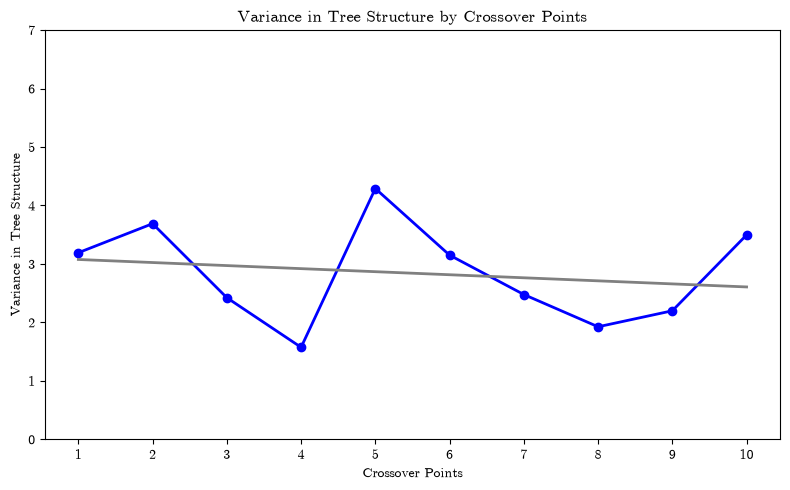

In [305]:
#plot variance in closeness to targets by crossover points
plt.figure(figsize=(8, 5))

plt.plot(
    stats_by_point["point"],
    stats_by_point["variance"],
    marker="o",
    linewidth=2,
    color="blue",
    label="Average Final Best"
)

# # Shaded SD
# plt.fill_between(
#     convergence_by_point["point"],
#     convergence_by_point["mean"] - convergence_by_point["std"],
#     convergence_by_point["mean"] + convergence_by_point["std"],
#     color="green",
#     alpha=0.2,
#     label="± SD"
# )

#add linear regression line
plt.plot( 
    x_line,
    y_line,
    color="grey",
    linewidth=2,
    label="Linear regression"
)


plt.ylim(0, 7)
plt.xticks(stats_by_point["point"])
plt.xlabel("Crossover Points")
plt.ylabel("Variance in Tree Structure")
plt.title("Variance in Tree Structure by Crossover Points")

plt.tight_layout()
fig.savefig("final_variance_graph.pdf", format="pdf", bbox_inches="tight")
fig.savefig("final_variance_graph.svg", format="svg", bbox_inches="tight")

plt.show()